# 2. Regularisation: lasso and elastic net

Shrinking the least-squares coefficients to trade a little bias for a reduction
in variance. Lasso uses an L1 penalty; the elastic net mixes L1 and L2 through a
weight `alpha`. Both are fitted by gradient descent and tuned by 5-fold
cross-validation.

In [1]:
import sys
sys.path.append("..")

import numpy as np

from src.data import load_airfoil_data, prepare_airfoil_xy, airfoil_feature_names
from src.preprocessing import standardise, apply_standardisation, add_intercept
from src.metrics import mse, rsquare, pred
from src.plotting import metrics_table
from src.results import record_result

from src.regularisation import fit_lasso, fit_elastic_net, coefficient_path
from src.model_selection import make_folds, sweep_lambda, grid_search_elastic_net, DEFAULT_SEED
from src.plotting import plot_curve, plot_coefficient_path

In [2]:
train_df, test_df = load_airfoil_data()
feature_names = airfoil_feature_names(train_df)

X_raw, y = prepare_airfoil_xy(train_df)
X_test_raw, y_test = prepare_airfoil_xy(test_df)

# Standardise on the training set, then reuse mu and sigma on the test set so
# both sit on the same scale.
X, mu, sigma = standardise(X_raw)
X_test = apply_standardisation(X_test_raw, mu, sigma)

# A column of ones lets the intercept be fitted as another weight.
X = add_intercept(X)
X_test = add_intercept(X_test)

print(f"train {X.shape}, test {X_test.shape}")
print("features:", feature_names)

train (3890, 7), test (973, 7)
features: ['Frequency', 'Angle', 'Displacement', 'Chord length', 'Velocity', 'Thickness']


## Lasso

The folds are built once, with a fixed seed, and reused for every hyperparameter
below — so lasso and the elastic net are tuned on exactly the same partition and
their scores are comparable.

In [3]:
folds = make_folds(len(y), 5, rng=DEFAULT_SEED)
print("fold sizes:", [len(f) for f in folds])

fold sizes: [778, 778, 778, 778, 778]


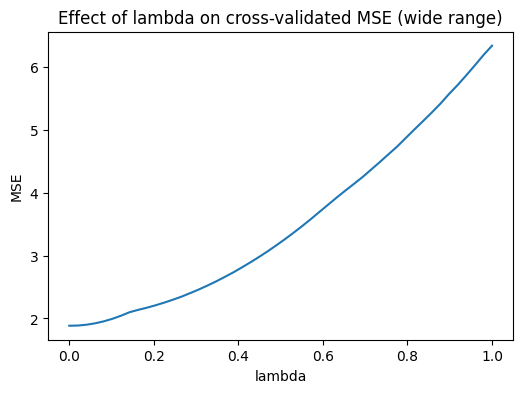

In [4]:
# A wide sweep first, to locate the neighbourhood of the optimum.
lambda_wide = np.linspace(0, 1, 50)
mse_wide = sweep_lambda(y, X, folds, lambda_wide, mse)

plot_curve(lambda_wide, mse_wide, "lambda", "MSE",
           "Effect of lambda on cross-validated MSE (wide range)")

The wide sweep shows the minimum sits in a neighbourhood close to zero, so the
search is repeated at much higher resolution over a narrow range.

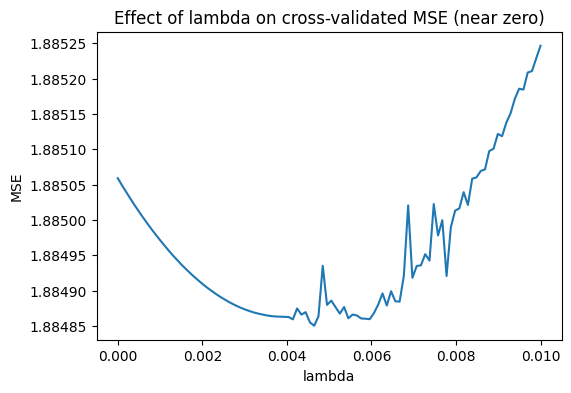

optimal lambda: 0.004646


In [5]:
lambda_fine = np.linspace(0, 0.01, 100)
mse_fine = sweep_lambda(y, X, folds, lambda_fine, mse)

plot_curve(lambda_fine, mse_fine, "lambda", "MSE",
           "Effect of lambda on cross-validated MSE (near zero)")

optimal_lambda = lambda_fine[int(np.argmin(mse_fine))]
print(f"optimal lambda: {optimal_lambda:.6f}")

### How lambda shrinks the coefficients

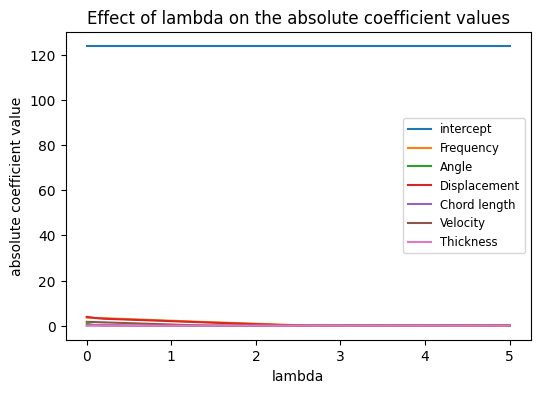

In [6]:
path_lambda = np.linspace(0, 5, 50)
path = coefficient_path(y, X, path_lambda, fit_lasso)

plot_coefficient_path(path_lambda, path, "lambda",
                      ["intercept"] + feature_names)

Every coefficient is driven towards zero as lambda grows, because the penalty
charges the loss increasingly for large absolute values. The exception is the
intercept, which is deliberately left unpenalised, and the strongest predictor,
which earns more from reducing the squared-error term than it costs in penalty.

The point of the shrinkage is to reduce the variance that comes from fitting an
over-complex model, at the cost of bias — the estimator is no longer unbiased.
Cross-validated MSE generally rises with lambda once the bias penalty outweighs
the variance saved, and the value selected above is the one that generalises best
to held-out folds. Pushed far enough, lasso converges on the null model, which
has no variance at all because every estimate is identical.

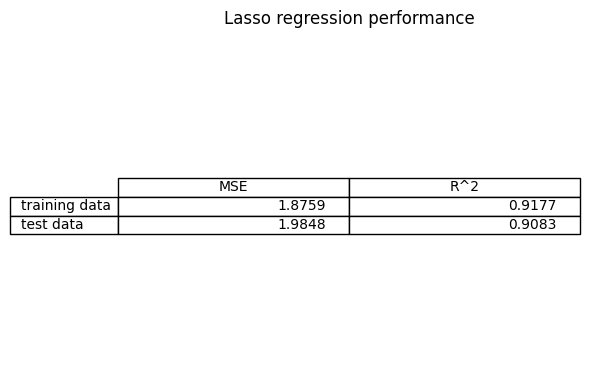

In [7]:
beta_lasso = fit_lasso(y, X, np.ones(X.shape[1]), optimal_lambda)

lasso_train = (mse(y, pred(X, beta_lasso)), rsquare(y, pred(X, beta_lasso)))
lasso_test = (mse(y_test, pred(X_test, beta_lasso)),
              rsquare(y_test, pred(X_test, beta_lasso)))

record_result("Lasso", "train", mse=lasso_train[0], r_squared=lasso_train[1])
record_result("Lasso", "test", mse=lasso_test[0], r_squared=lasso_test[1])

metrics_table([list(lasso_train), list(lasso_test)],
              columns=("MSE", "R^2"),
              row_labels=("training data", "test data"),
              title="Lasso regression performance")

The MSE rises from the training to the test set, but the effect on predictive
power is slight, as the R^2 shows. At lambda = 0 this would reduce to the plain
least-squares estimator; the selected lambda instead shrinks the coefficients a
little, and the R^2 comparison against notebook 01 shows whether that trade was
worthwhile on this data. The shrinkage towards zero would be far more dramatic on
unstandardised features.

## Elastic net

The elastic net is worth trying because it reveals whether a ridge (L2) term
helps on this data, or whether some mixture of the two penalties does better than
either alone. The objective is

    RSS/(2N) + l * (alpha * ||b||_1 + (1 - alpha) * ||b||_2^2)

so `alpha = 1` recovers lasso and `alpha = 0` gives ridge regression.

In [8]:
alpha_values = np.array((0.1, 0.5, 0.9))
en_lambda_values = np.linspace(0, 0.01, 201)

en_results = grid_search_elastic_net(y, X, folds, en_lambda_values, alpha_values, mse)

for alpha, best_lambda, best_score in en_results:
    print(f"alpha {alpha:.1f}: optimal lambda {best_lambda:.6f}, CV MSE {best_score:.4f}")

alpha 0.1: optimal lambda 0.000000, CV MSE 1.8851
alpha 0.5: optimal lambda 0.000050, CV MSE 1.8851
alpha 0.9: optimal lambda 0.001650, CV MSE 1.8850


The optimal lambda tends to rise with alpha. As the ridge term contributes less,
the overall shrinkage term has to contribute more — which is to say the model
favours the lasso penalty on this data.

alpha 0.1: test MSE 1.9848, test R^2 0.9083
alpha 0.5: test MSE 1.9849, test R^2 0.9083
alpha 0.9: test MSE 1.9854, test R^2 0.9083


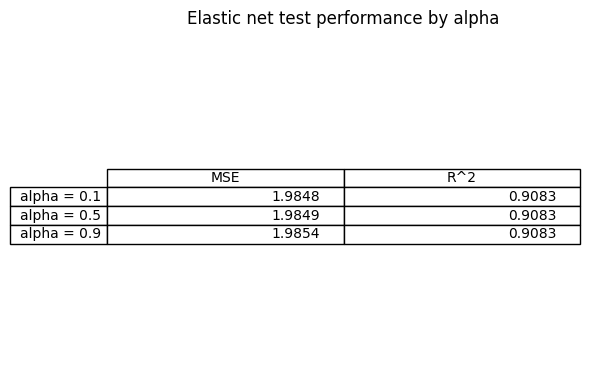

In [9]:
betas_by_alpha = {
    alpha: fit_elastic_net(y, X, np.ones(X.shape[1]), best_lambda, alpha)
    for alpha, best_lambda, _ in en_results
}

rows = []
for alpha, beta in betas_by_alpha.items():
    y_hat = pred(X_test, beta)
    rows.append([mse(y_test, y_hat), rsquare(y_test, y_hat)])
    print(f"alpha {alpha:.1f}: test MSE {rows[-1][0]:.4f}, test R^2 {rows[-1][1]:.4f}")

metrics_table(rows, columns=("MSE", "R^2"),
              row_labels=[f"alpha = {a}" for a in betas_by_alpha],
              title="Elastic net test performance by alpha")

In [10]:
best_alpha = max(
    betas_by_alpha,
    key=lambda a: rsquare(y_test, pred(X_test, betas_by_alpha[a])),
)
beta_en = betas_by_alpha[best_alpha]
print(f"best alpha: {best_alpha}")

en_train = (mse(y, pred(X, beta_en)), rsquare(y, pred(X, beta_en)))
en_test = (mse(y_test, pred(X_test, beta_en)), rsquare(y_test, pred(X_test, beta_en)))

record_result("Elastic net", "train", mse=en_train[0], r_squared=en_train[1])
record_result("Elastic net", "test", mse=en_test[0], r_squared=en_test[1])

best alpha: 0.1


,model,split,mse,r_squared
0,Elastic net,test,1.984829,0.908297
1,Elastic net,train,1.875560,0.917734
2,Lasso,test,1.984805,0.908298
3,Lasso,train,1.875886,0.917720
4,Least squares,test,1.984390,0.908317
5,Least squares,train,1.875557,0.917734


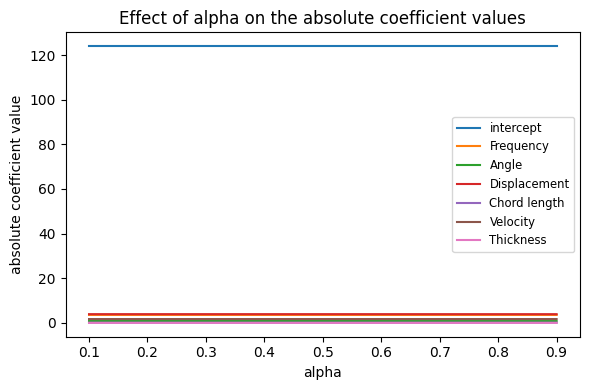

In [11]:
coefficients = np.array([np.abs(betas_by_alpha[a]) for a in betas_by_alpha])

plot_coefficient_path(list(betas_by_alpha.keys()), coefficients, "alpha",
                      ["intercept"] + feature_names)

## Discussion

At `alpha = 0` the L1 term drops out entirely and the model is doing ridge
regression. At `alpha = 0.5` the two norms contribute equally, balancing the
L1 term's tendency to drive coefficients to exactly zero against the L2 term's
tendency to shrink them smoothly. At `alpha = 1` the L2 term vanishes and the
result matches the lasso fitted above.

Across the alphas tested the differences are small, which says the ridge term
adds little here — but the gain from the whole exercise is modest either way. The
coefficients generally shrink as alpha increases, again because the L1 term
induces sparsity more aggressively than the L2 term.

**Next:** [03_knn_regression.ipynb](03_knn_regression.ipynb)